In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import root_mean_squared_error

from external.pykernels.pykernels.basic import Linear, RBF, Polynomial

In [ ]:
# documentary comment: function to approximate is a  vectorised function
# note that this can be done way more easily with scikit learn as a black box funciton
# TODO das ganze für 2D workking machen

def sin_function(x):
    return np.sin(2*x+3)-1

def polynome2_function(x):
    return 3*x**2 + 4*x - 5

def polynome4_function(x):
    return x**4 - 0.5*x**3 + x -1

def exp_function(x):
    return 0.1*np.exp(-0.5*x)

# if noise_index was 1 then same magnitude of noise as signal - regression difficult
def gaussian_noise(y_values, noise_index, rng=None):
    std_noise = noise_index * np.std(y_values)
    gaussian_noise = rng.normal(0, std_noise, len(y_values))
    return gaussian_noise, std_noise

# def kernel_function(x1, x2, kernel='RBF'):
    if kernel == 'Polynomial':
        return 


In [7]:
METRIC = root_mean_squared_error # TODO wird momentan nicht genutzt
# Negative Log Predictive Density und Log Marginal Likelihood sind anscheinend GP spezifische metriken, die man reporten könnte, verstehe ich aber nicht TODO

In [8]:
# man könnte wie in scikit learn auch Hyperparametersuche über alpha machen und damit das noise lernen (mit white kernel) - aber das lassen wir hier!
class GPR_regressor:
    # TODO change kernel functiomn default
    def __init__(self, kernel=RBF()):
        self.c = None
        self.x_train = None
        self.kernel = kernel

    def _ensure_2d(self, X):
        X = np.asarray(X)
        if X.ndim == 0:
            X = X.reshape(1, 1)
        elif X.ndim == 1:
            X = X.reshape(-1, 1)
        return X

    def fit(self, x_train, y_train): # TODO was wenn fit zweimal aufgerufen wird?
        self.fit_known_noise_std(x_train, y_train, 0.1)

    def fit_known_noise_std(self, x_train, y_train, noise_std):
        x_train = self._ensure_2d(x_train)       
        dim = len(x_train)
        KNN = self.kernel(x_train, x_train)
        to_invert = KNN + noise_std**2 * np.identity(dim)
        self.c = np.linalg.solve(to_invert, y_train)
        self.x_train = x_train

    def predict(self, x_test):
        x_test = self._ensure_2d(x_test)
        if self.c is not None: # TODO was wenn x_test nur eine zahl ist - klappt kernel function dann noch?
            kernel_distances = self.kernel(self.x_train, x_test)
            y_pred = np.dot(self.c, kernel_distances)
            return y_pred
        else:
            print("The model has not been trained before trying to predict!")
            return None

    def evaluate(self, x_test, y_true, metric=root_mean_squared_error, verbose=False):
        # estimate a metric on the given set
        # this method does not use the same metric as test() but rather the classic metric that we know to make it comparable with the other
        y_pred = self.predict(x_test)
        if y_pred is None:
            raise ValueError("Prediction cannot be None. Is the model trained?")
        met = metric(y_true, y_pred)

        if verbose:
            print(f"Achieved {met}")
        return met

In [29]:
def create_noised_train_set(function_to_approximate, x_train, noise_index=0.1, lower_boundary=-5, upper_boundary=5):
    y_without_noise = function_to_approximate(x_train)
    gaussian_noise_, noise_std = gaussian_noise(y_without_noise, noise_index, rng)
    y_train = y_without_noise + gaussian_noise_

    return y_train, noise_std

def gamma_from_length_scale(length_scale):
    return 1/(2*length_scale**2)

In [31]:
def create_regressor(x_train, function_to_investigate_string, basis_functions_string, length_scale=0.5, polynomial_degree=3, noise_index=0.1):
    gamma = gamma_from_length_scale(length_scale)

    function_to_investigate = sin_function
    if function_to_investigate_string == 'polynome2':
        function_to_investigate = polynome2_function
    elif function_to_investigate_string == 'polynome4': # nimm polynom von grad 4 oder 5
        function_to_investigate = polynome4_function
    elif function_to_investigate_string == 'polynome7':
        function_to_investigate = polynome7_function
    elif function_to_investigate_string == 'exp':
        function_to_investigate = exp_function


    basis_functions = Linear()
    basis_functions_verbose = 'Linear'
    if basis_functions_string == 'Polynomial':
        basis_functions = Polynomial(polynomial_degree)
        basis_functions_verbose = f'Polynomial_{polynomial_degree}'
    elif basis_functions_string == 'RBF':
        basis_functions = RBF(gamma)
        basis_functions_verbose = f'RBF_{length_scale}'

    y_train, noise_std_train = create_noised_train_set(function_to_investigate, x_train, noise_index, lower_boundary, upper_boundary)
    regressor = GPR_regressor(basis_functions)
    regressor.fit(x_train, y_train)
    return regressor, function_to_investigate, basis_functions_verbose

# regressor = GPR_regressor(Polynomial(degree=2)) # space that is spanned by these basis functions is only the space of polynomials up to degree 2 TODO


In [27]:
function_to_investigate_string = 'exp' # TODO das ist eine sehr hässliche art und weise das zu programmieren aber mei wir machen ja nicht auf robustheit
number_of_training_samples = 20
length_scale = 0.5
basis_functions_string = 'RBF'
polynomial_degree = 4 # TODO discuss man sieht die form der basis functions
noise_index = 0.05
# TODO über uncertainty reden

lower_boundary = -5
upper_boundary = 5

rng = np.random.default_rng(42)

# regressor, function_to_investigate, x_train, basis_functions_verbose = create_regressor(function_to_investigate_string, basis_functions_string, number_of_training_samples, rng, length_scale, polynomial_degree, noise_index, lower_boundary, upper_boundary)

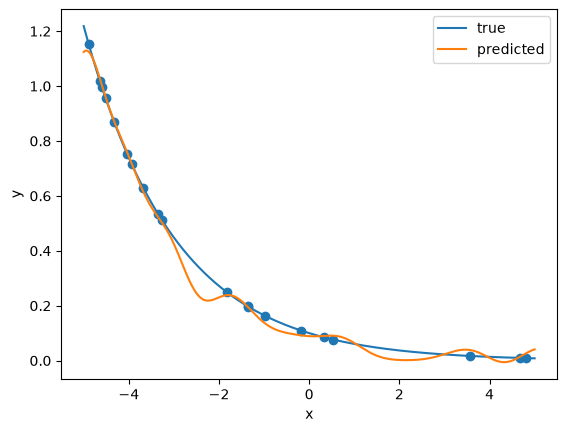

In [ ]:
x_all = np.linspace(lower_boundary, upper_boundary, 1000)
y_all_true = function_to_investigate(x_all)
y_all_predicted = regressor.predict(x_all)
y_train = function_to_investigate(x_train)
# TODO x_train punkte markieren und mit verschiedenen anzahlen davon ausprobieren und verschiedener menge noise und verschiedenen kernels

plt.plot(x_all, y_all_true, label = "true")
plt.plot(x_all, y_all_predicted, label = "predicted")
plt.scatter(x_train, y_train)
plt.xlabel("x")
plt.ylabel(r"y")
plt.legend()
# plt.savefig(f"Task_1_{basis_functions_verbose}_n_{number_of_training_samples}_{function_to_investigate_string}_noise_{noise_index}.png", dpi=300, bbox_inches="tight")
plt.show()

# Hyperparameter to vary TODO: gamma in RBF, ggf auch mal linear kernel, wie viele stützpunkte, regulazierer, welche function, amount of noise und ob es known ist oder nicht - ist letzteres das was sagt ob regularizer zu groß oder passend ist?

# TODO über sparse GPR sprechen - committee error nur dabei relevant nicht bei unserm full GPR
# so nen TODO schönen error plot machen wie auf folie 26?
# TODO hyperparam search over gamma
# TODO regulazier small oder groß wählen? Was heißt groß oder klein überhaupt? Figure 3 caption

[0.05       0.08340503 0.13912797 0.23207944 0.38713184 0.64577483
 1.07721735 1.79690683 2.99742125 5.        ]


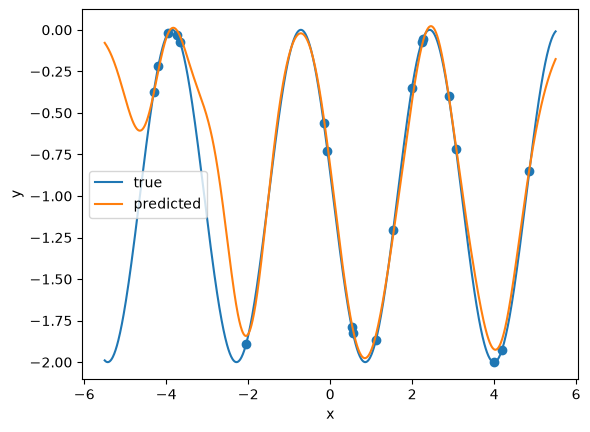

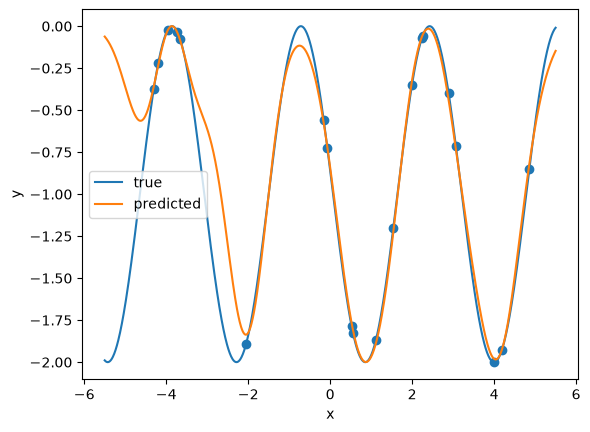

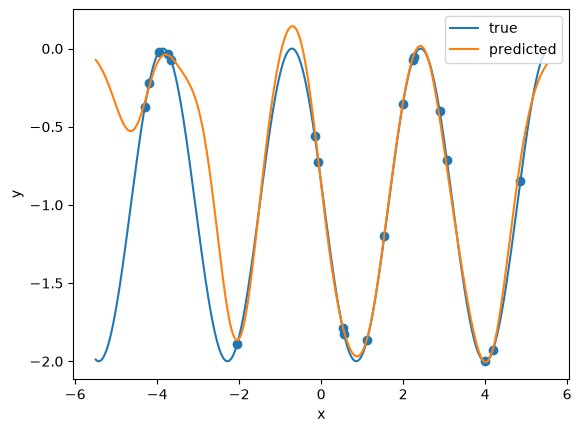

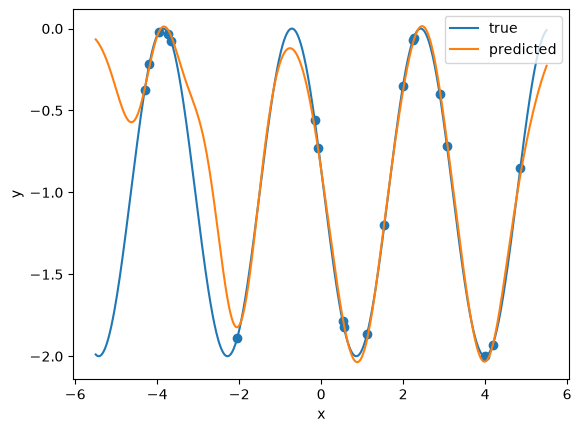

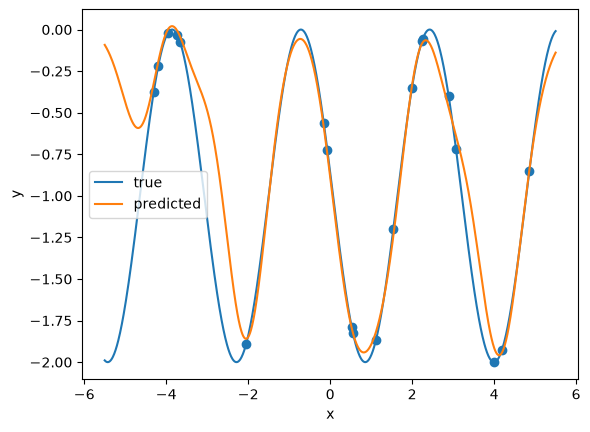

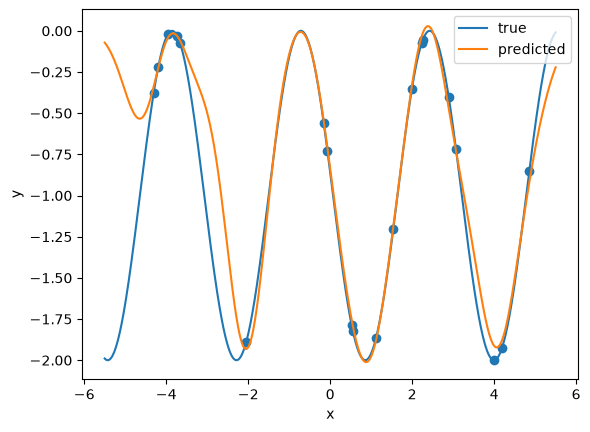

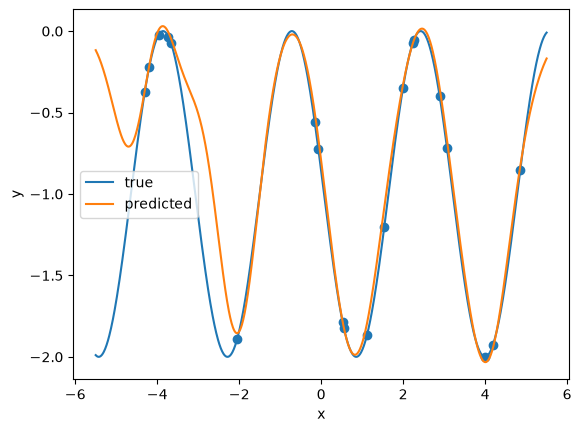

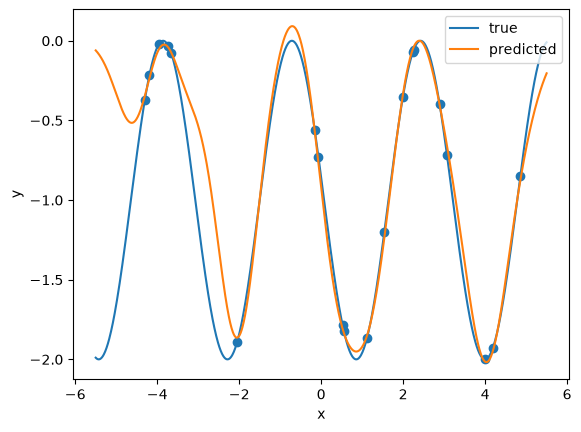

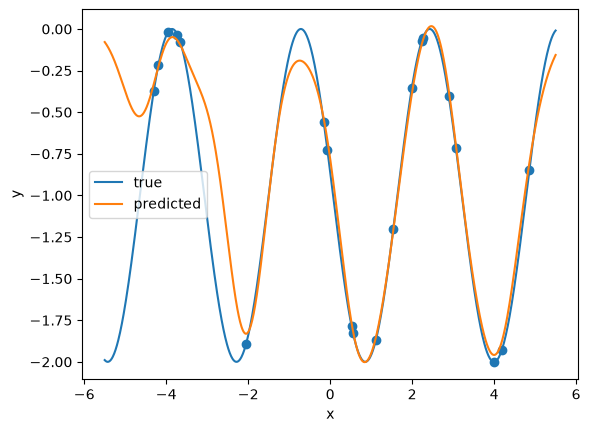

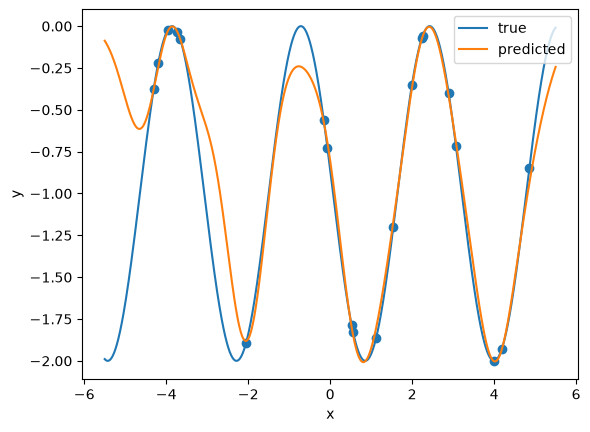

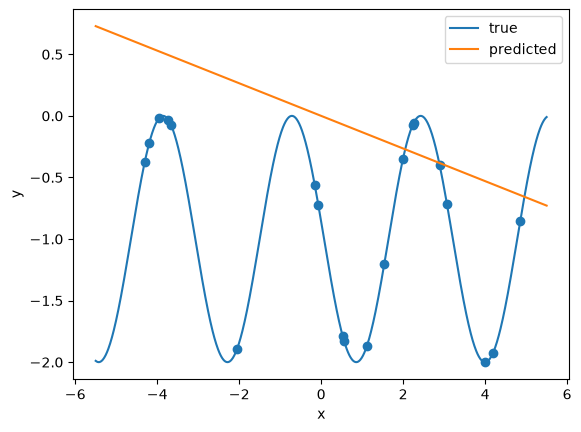

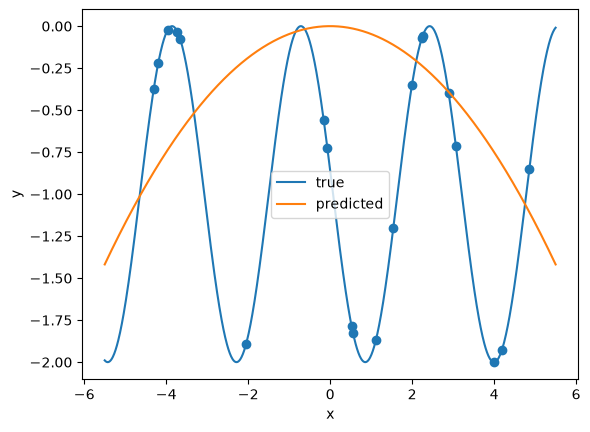

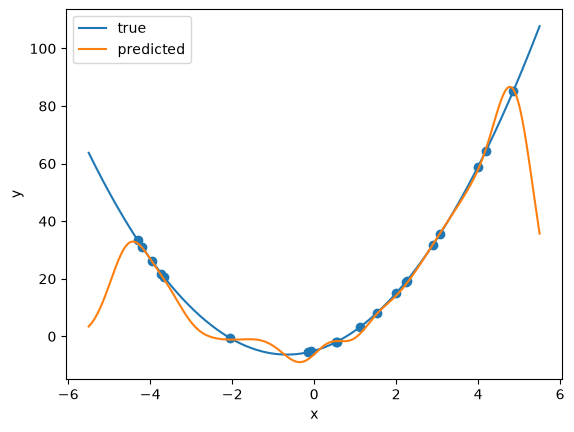

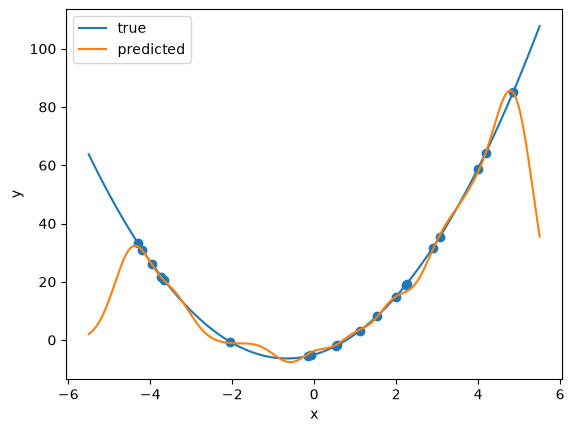

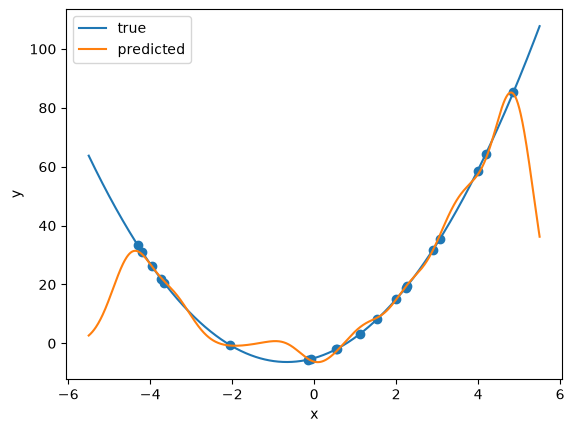

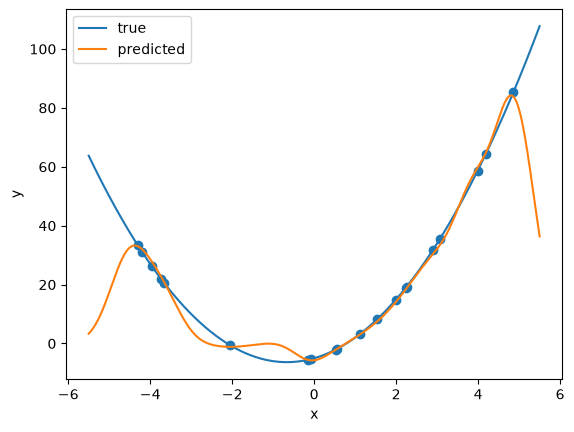

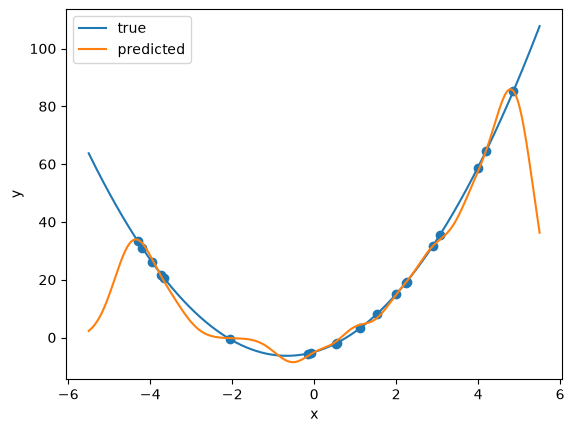

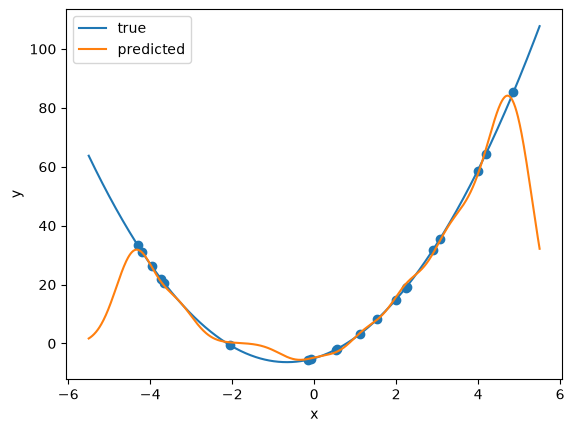

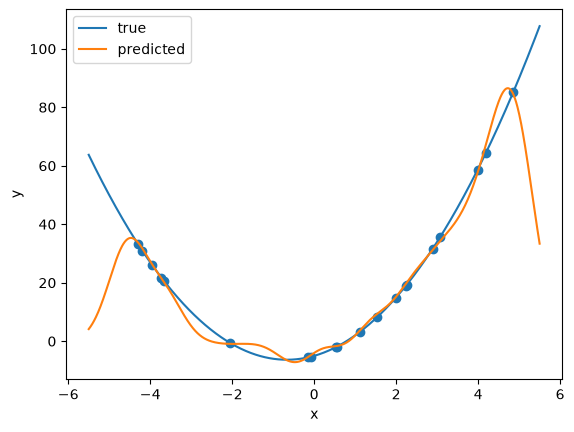

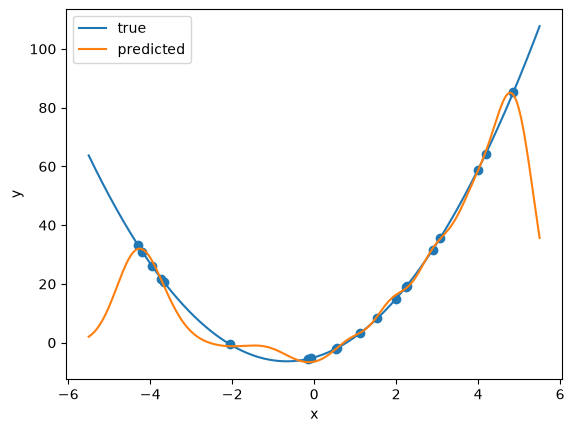

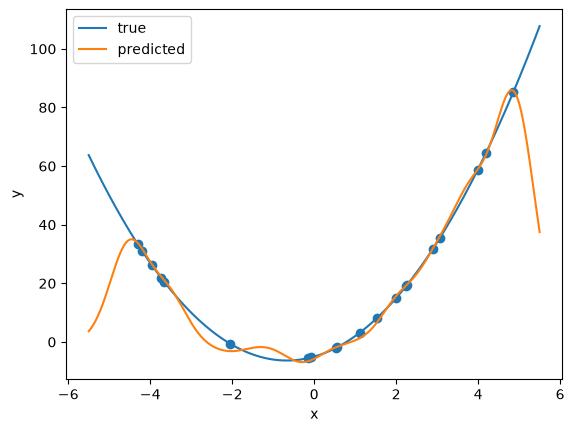

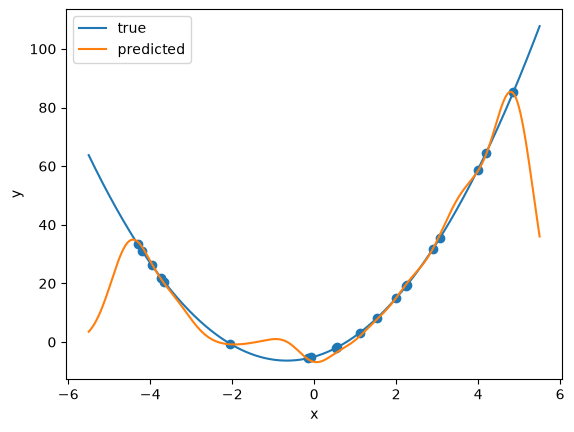

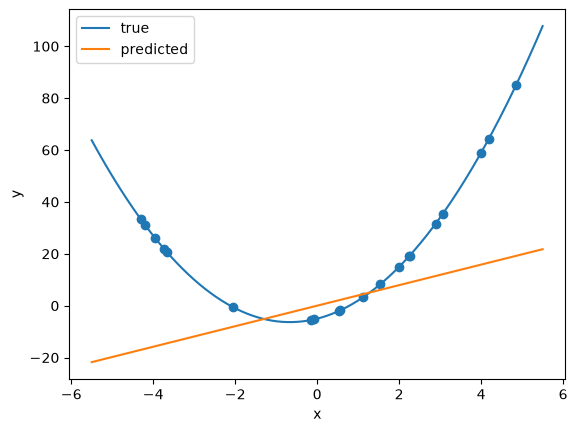

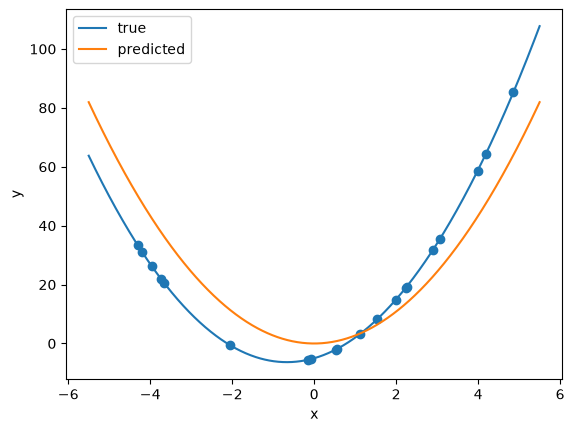

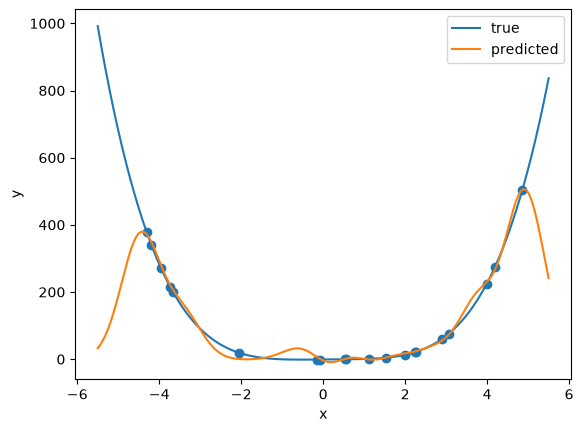

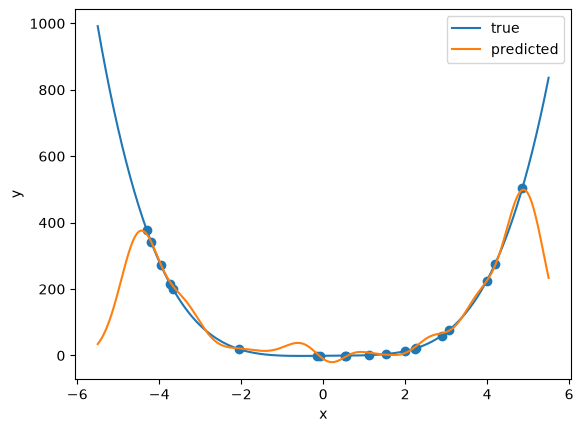

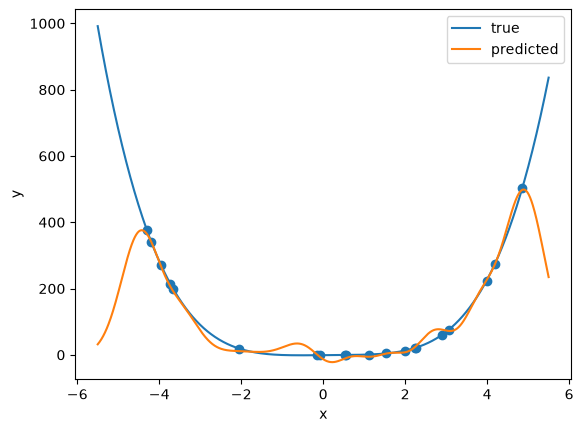

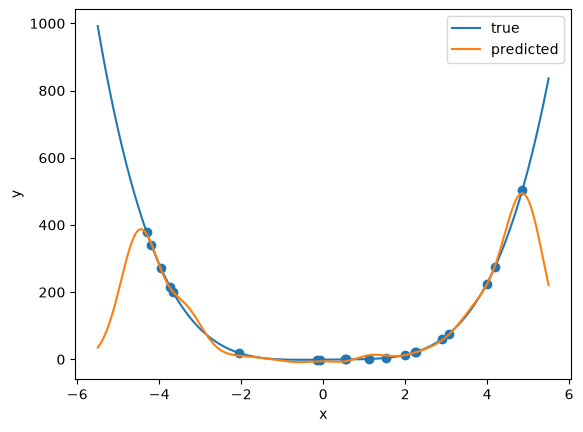

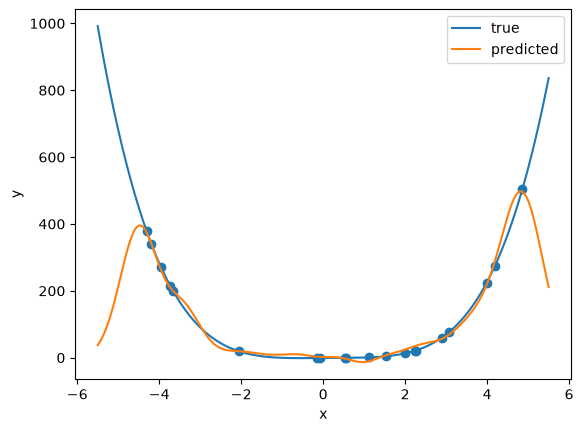

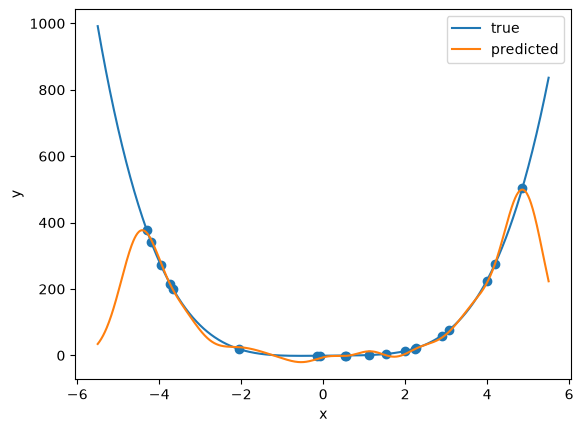

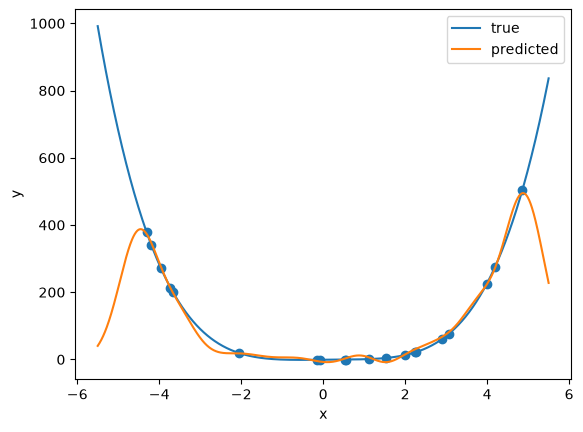

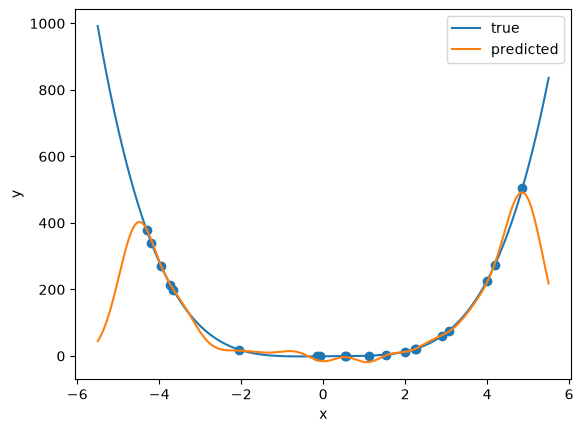

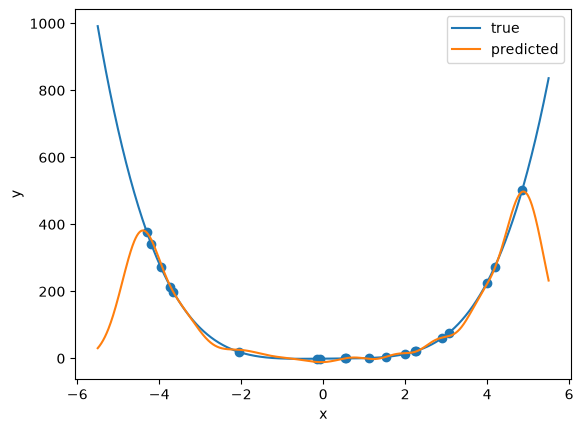

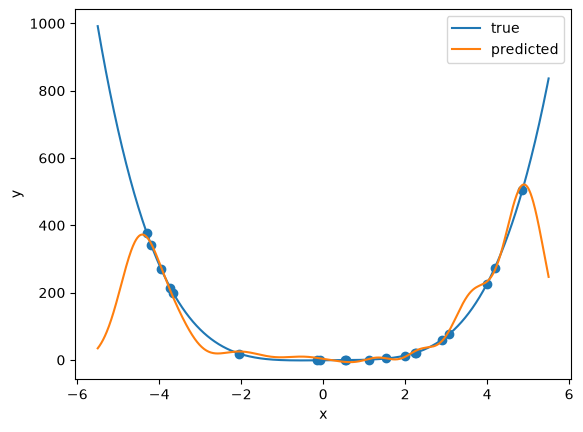

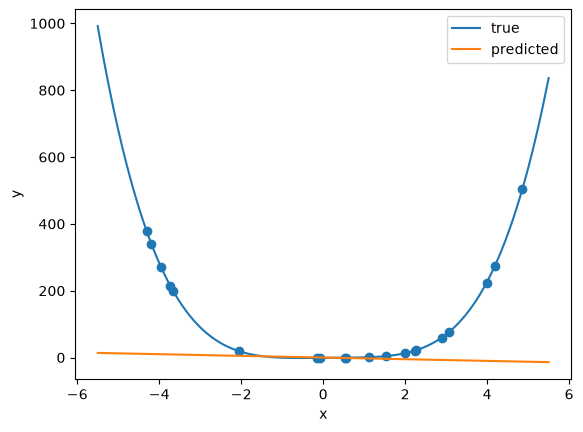

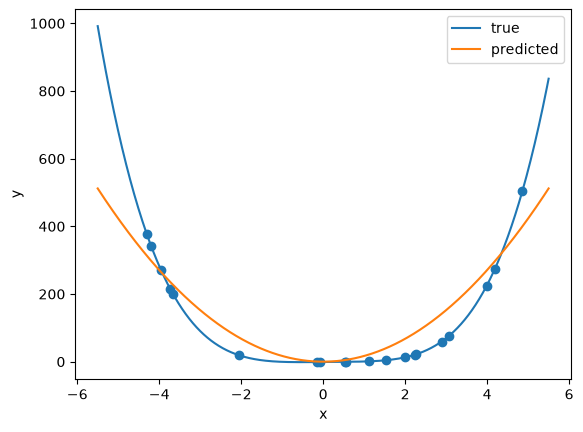

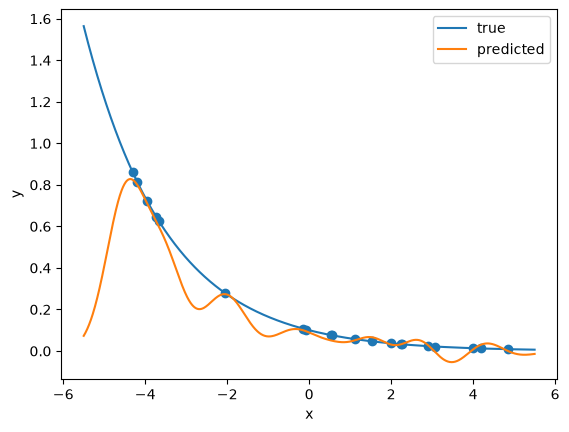

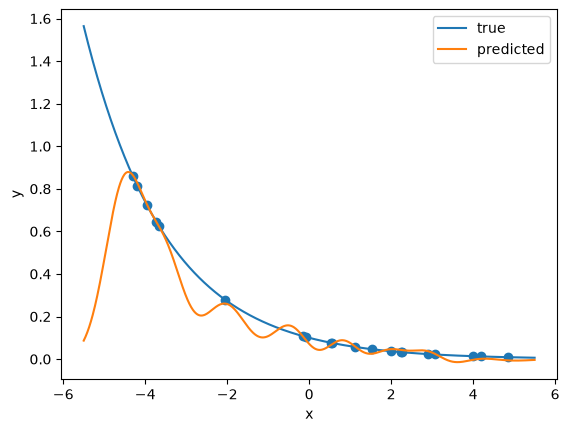

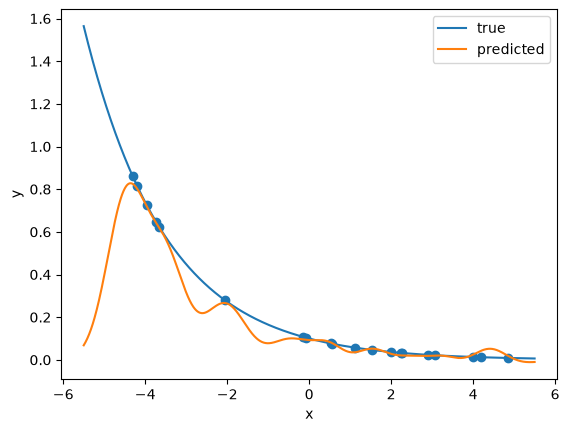

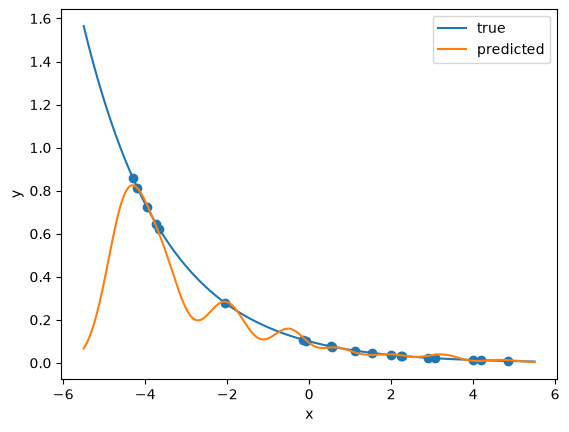

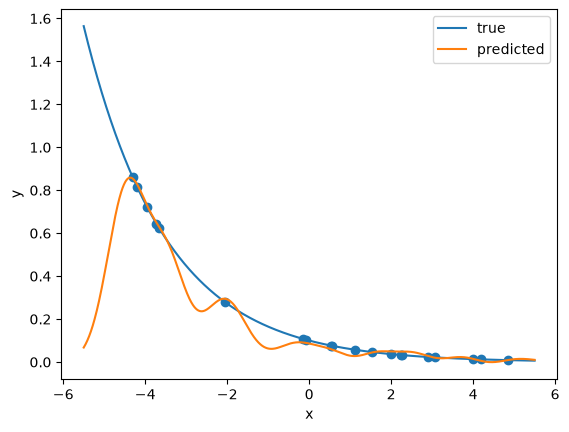

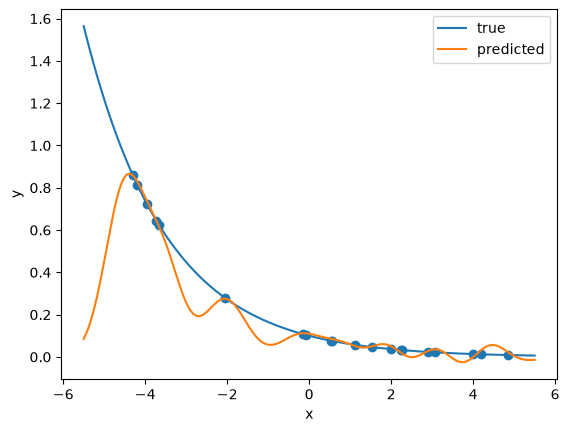

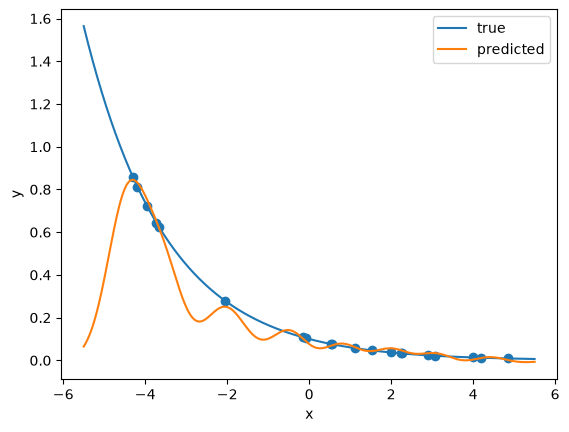

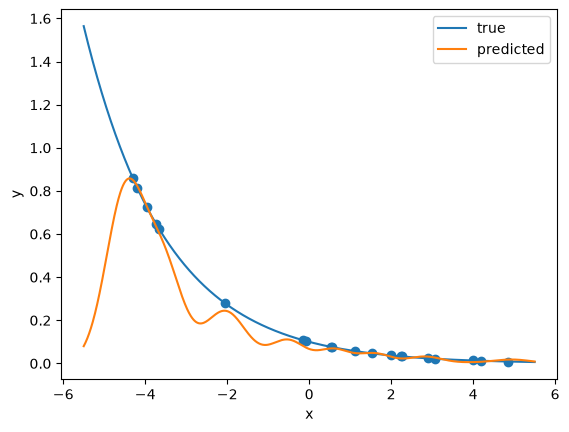

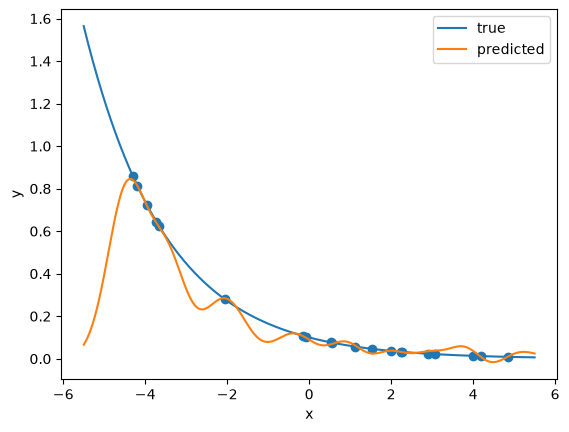

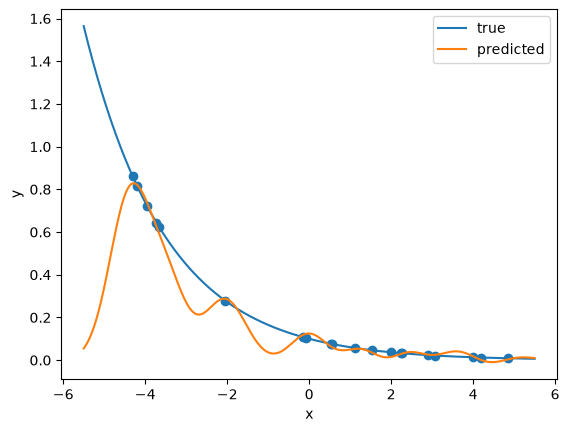

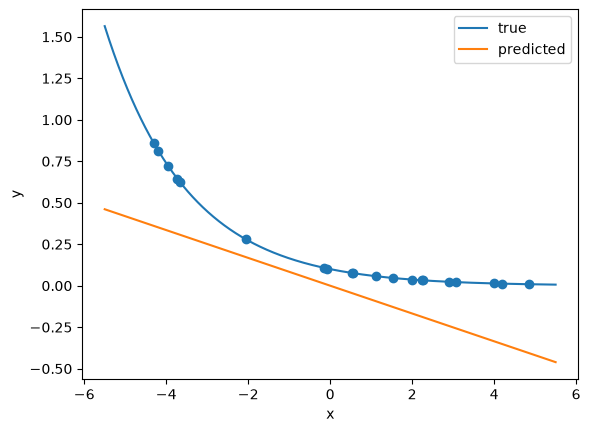

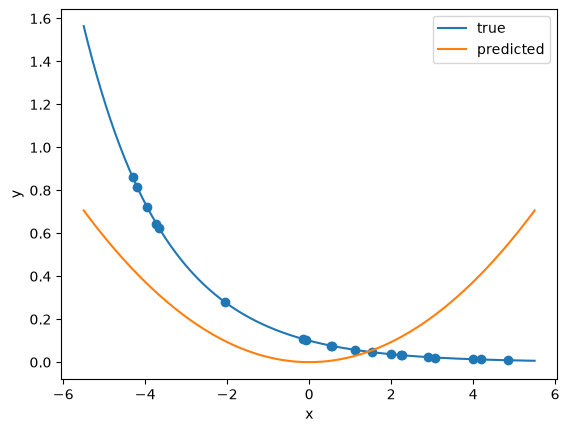

Function sin with basis functions RBF and length scale 0.049999999999999996 achieved RSME 0.3525794872913634
Function sin with basis functions RBF and length scale 0.08340502686000295 achieved RSME 0.3514709295561993
Function sin with basis functions RBF and length scale 0.1391279701103562 achieved RSME 0.3968279284520549
Function sin with basis functions RBF and length scale 0.2320794416806389 achieved RSME 0.36308411781595434
Function sin with basis functions RBF and length scale 0.38713184134056344 achieved RSME 0.37308066358649183
Function sin with basis functions RBF and length scale 0.6457748325074419 achieved RSME 0.3682470320393452
Function sin with basis functions RBF and length scale 1.0772173450159415 achieved RSME 0.3278032689844917
Function sin with basis functions RBF and length scale 1.7969068319023125 achieved RSME 0.37505885303596104
Function sin with basis functions RBF and length scale 2.997421251594704 achieved RSME 0.3800374670785919
Function sin with basis functio

In [43]:
from sklearn.metrics import root_mean_squared_error

functions = ['sin', 'polynome2', 'polynome4', 'exp']
basis_functions = ['RBF', 'Linear', 'Polynomial']
length_scales = [0.001, 0.1, 0.5, 1, 10, 100]

rsme_output = ""


x_test = rng.uniform(lower_boundary, upper_boundary, size=100)
x_train = rng.uniform(lower_boundary, upper_boundary, size=number_of_training_samples)


domain_width = upper_boundary - lower_boundary
typical_spacing = domain_width / number_of_training_samples

length_scales = np.logspace(
    np.log10(0.1 * typical_spacing),
    np.log10(10 * typical_spacing),
    10
)

rsme_length_scales = np.zeros((len(functions), len(length_scales)))


print(length_scales)

for i, function_to_investigate_string in enumerate(functions):
    for basis_function_string in basis_functions:

        if basis_function_string == "RBF":
            length_scales_to_test =  length_scales

        else:
            length_scales_to_test = [0.5] # this number does not matter in that case

        for j, current_length_scale in enumerate(length_scales_to_test):
            regressor, function_to_investigate, basis_functions_verbose = create_regressor(x_train, function_to_investigate_string, basis_function_string, length_scale, polynomial_degree, noise_index)
    
            y_test = function_to_investigate(x_test)
            y_test_predicted = regressor.predict(x_test)
            rmse = root_mean_squared_error(y_test, y_test_predicted) / np.std(y_test)
            if basis_function_string == "RBF":
                rsme_output += f"Function {function_to_investigate_string} with basis functions {basis_function_string} and length scale {current_length_scale} achieved RSME {rmse}\n"
                rsme_length_scales[i][j] = rmse
            else:
                rsme_output += f"Function {function_to_investigate_string} with basis functions {basis_function_string} achieved RSME {rmse}\n"

            x_all = np.linspace(lower_boundary-0.5, upper_boundary+0.5, 1000)
            y_all_true = function_to_investigate(x_all)
            y_all_predicted = regressor.predict(x_all)
            y_train = function_to_investigate(x_train)

            plt.plot(x_all, y_all_true, label = "true")
            plt.plot(x_all, y_all_predicted, label = "predicted")
            plt.scatter(x_train, y_train)
            plt.xlabel("x")
            plt.ylabel(r"y")
            plt.legend()
            filename = f"plots/Task_1_second_version_{basis_functions_verbose}_n_{number_of_training_samples}_{function_to_investigate_string}_noise_{noise_index}.png"
            if basis_function_string == "RBF":
                filename = f"plots/Task_1_second_version_{basis_functions_verbose}_length_scale_{current_length_scale}_n_{number_of_training_samples}_{function_to_investigate_string}_noise_{noise_index}.png"
            plt.savefig(filename, dpi=300, bbox_inches="tight")
            plt.show()

print(rsme_output)

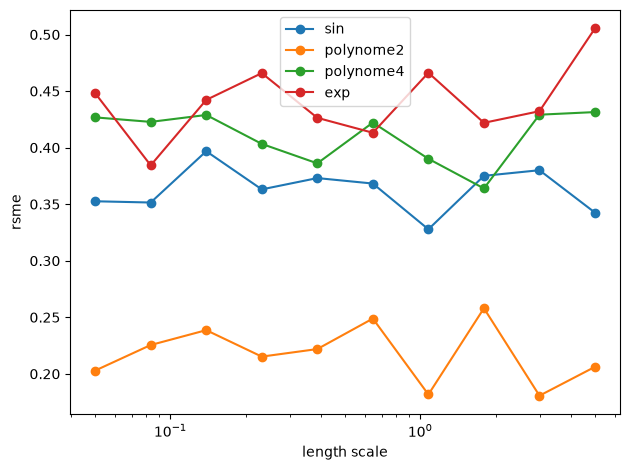

In [ ]:
plt.figure()

for i in range(rsme_length_scales.shape[0]):
    plt.plot(length_scales, rsme_length_scales[i], marker="o", label=f"{functions[i]}")

plt.xlabel("length scale")
plt.xscale("log")
plt.ylabel("rsme")
plt.legend()
plt.tight_layout()
plt.savefig("plots/rsme_over_length_scale", dpi = 300) # TODO wenn ich den plot benutze, noch hüscher machen!
plt.show()

In [8]:
# this is the hardcoded derivative because it is just used to illustrate
def derivative_of_sin_function(x):
    return 2*np.cos(2*x+3)


In [ ]:
import numpy as np


class RBFWithDerivatives1D:
    def __init__(self, length_scale=1.0, variance=1.0):
        self.length_scale = length_scale
        self.variance = variance

    def k(self, X, Y):
        r = X - Y.T
        ell2 = self.length_scale ** 2

        return self.variance * np.exp(-0.5 * r**2 / ell2)

    def k_f_d(self, X, Z):
        """
        Cov(f(X), f'(Z))
        """

        K = self.k(X, Z)
        r = X - Z.T
        ell2 = self.length_scale ** 2

        return K * r / ell2

    def k_d_f(self, Z, X):
        """
        Cov(f'(Z), f(X))
        """

        K = self.k(Z, X)
        r = Z - X.T
        ell2 = self.length_scale ** 2

        return -K * r / ell2

    def k_d_d(self, Z1, Z2):
        """
        Cov(f'(Z1), f'(Z2))
        """

        K = self.k(Z1, Z2)
        r = Z1 - Z2.T
        ell = self.length_scale

        return K * (1 / ell**2 - r**2 / ell**4)

In [ ]:
class GPRWithDerivativeObservations1D:
    def __init__(self, kernel=None):
        self.kernel = kernel if kernel is not None else RBFWithDerivatives1D()
        self.alpha = None
        self.X_value = None
        self.X_deriv = None

    def _ensure_2d(self, X):
        X = np.asarray(X, dtype=float)
        if X.ndim == 0:
            X = X.reshape(1, 1)
        elif X.ndim == 1:
            X = X.reshape(-1, 1)
        return X


    def fit(
        self,
        X_value=None,
        y_value=None,
        X_deriv=None,
        y_deriv=None,
        noise_value_std=1e-6,
        noise_deriv_std=1e-6
    ):
        blocks = []
        y_parts = []

        has_values = X_value is not None and y_value is not None
        has_derivs = X_deriv is not None and y_deriv is not None

        if not has_values and not has_derivs:
            raise ValueError("Need at least function values or derivative values.")

        if has_values:
            X_value = self._ensure_2d(X_value)
            y_value = np.asarray(y_value, dtype=float).ravel()
            y_parts.append(y_value)

        if has_derivs:
            X_deriv = self._ensure_2d(X_deriv)
            y_deriv = np.asarray(y_deriv, dtype=float).ravel()
            y_parts.append(y_deriv)

        if has_values and has_derivs:
            K_ff = self.kernel.k(X_value, X_value)
            K_fd = self.kernel.k_f_d(X_value, X_deriv)
            K_df = self.kernel.k_d_f(X_deriv, X_value)
            K_dd = self.kernel.k_d_d(X_deriv, X_deriv)

            K = np.block([
                [K_ff, K_fd],
                [K_df, K_dd]
            ])

            noise = np.concatenate([
                noise_value_std**2 * np.ones(len(X_value)),
                noise_deriv_std**2 * np.ones(len(X_deriv))
            ])

        elif has_values:
            K = self.kernel.k(X_value, X_value)
            noise = noise_value_std**2 * np.ones(len(X_value))

        else:
            K = self.kernel.k_d_d(X_deriv, X_deriv)
            noise = noise_deriv_std**2 * np.ones(len(X_deriv))

        y_obs = np.concatenate(y_parts)

        K_noisy = K + np.diag(noise)

        self.alpha = np.linalg.solve(K_noisy, y_obs)
        self.X_value = X_value if has_values else None
        self.X_deriv = X_deriv if has_derivs else None


    def fit_derivative(
        self,
        X_value=None,
        y_value=None,
        X_deriv=None,
        y_deriv=None,
        noise_value_std=1e-6,
        noise_deriv_std=1e-6
    ):
        blocks = []
        y_parts = []

        has_values = X_value is not None and y_value is not None
        has_derivs = X_deriv is not None and y_deriv is not None

        if not has_values and not has_derivs:
            raise ValueError("Need at least function values or derivative values.")

        if has_values:
            X_value = self._ensure_2d(X_value)
            y_value = np.asarray(y_value, dtype=float).ravel()
            y_parts.append(y_value)

        if has_derivs:
            X_deriv = self._ensure_2d(X_deriv)
            y_deriv = np.asarray(y_deriv, dtype=float).ravel()
            y_parts.append(y_deriv)

        if has_values and has_derivs:
            K_ff = self.kernel.k(X_value, X_value)
            K_fd = self.kernel.k_f_d(X_value, X_deriv)
            K_df = self.kernel.k_d_f(X_deriv, X_value)
            K_dd = self.kernel.k_d_d(X_deriv, X_deriv)

            K = np.block([
                [K_ff, K_fd],
                [K_df, K_dd]
            ])

            noise = np.concatenate([
                noise_value_std**2 * np.ones(len(X_value)),
                noise_deriv_std**2 * np.ones(len(X_deriv))
            ])

        elif has_values:
            K = self.kernel.k(X_value, X_value)
            noise = noise_value_std**2 * np.ones(len(X_value))

        else:
            K = self.kernel.k_d_d(X_deriv, X_deriv)
            noise = noise_deriv_std**2 * np.ones(len(X_deriv))

        y_obs = np.concatenate(y_parts)

        K_noisy = K + np.diag(noise)

        self.alpha = np.linalg.solve(K_noisy, y_obs)
        self.X_value = X_value if has_values else None
        self.X_deriv = X_deriv if has_derivs else None


    def fit_values_and_derivative(
        self,
        X_value=None,
        y_value=None,
        X_deriv=None,
        y_deriv=None,
        noise_value_std=1e-6,
        noise_deriv_std=1e-6
    ):
        blocks = []
        y_parts = []

        has_values = X_value is not None and y_value is not None
        has_derivs = X_deriv is not None and y_deriv is not None

        if not has_values and not has_derivs:
            raise ValueError("Need at least function values or derivative values.")

        if has_values:
            X_value = self._ensure_2d(X_value)
            y_value = np.asarray(y_value, dtype=float).ravel()
            y_parts.append(y_value)

        if has_derivs:
            X_deriv = self._ensure_2d(X_deriv)
            y_deriv = np.asarray(y_deriv, dtype=float).ravel()
            y_parts.append(y_deriv)

        if has_values and has_derivs:
            K_ff = self.kernel.k(X_value, X_value)
            K_fd = self.kernel.k_f_d(X_value, X_deriv)
            K_df = self.kernel.k_d_f(X_deriv, X_value)
            K_dd = self.kernel.k_d_d(X_deriv, X_deriv)

            K = np.block([
                [K_ff, K_fd],
                [K_df, K_dd]
            ])

            noise = np.concatenate([
                noise_value_std**2 * np.ones(len(X_value)),
                noise_deriv_std**2 * np.ones(len(X_deriv))
            ])

        elif has_values:
            K = self.kernel.k(X_value, X_value)
            noise = noise_value_std**2 * np.ones(len(X_value))

        else:
            K = self.kernel.k_d_d(X_deriv, X_deriv)
            noise = noise_deriv_std**2 * np.ones(len(X_deriv))

        y_obs = np.concatenate(y_parts)

        K_noisy = K + np.diag(noise)

        self.alpha = np.linalg.solve(K_noisy, y_obs)
        self.X_value = X_value if has_values else None
        self.X_deriv = X_deriv if has_derivs else None

    def predict_function(self, X_test):
        X_test = self._ensure_2d(X_test)

        if self.alpha is None:
            raise ValueError("Model has not been fitted.")

        k_parts = []

        if self.X_value is not None:
            k_parts.append(self.kernel.k(self.X_value, X_test))

        if self.X_deriv is not None:
            # Cov(f'(z), f(x_*))
            k_parts.append(self.kernel.k_d_f(self.X_deriv, X_test))

        K_obs_test = np.vstack(k_parts)

        return K_obs_test.T @ self.alpha

    def predict_derivative(self, X_test):
        X_test = self._ensure_2d(X_test)

        if self.alpha is None:
            raise ValueError("Model has not been fitted.")

        k_parts = []

        if self.X_value is not None:
            # Cov(f(x), f'(x_*))
            k_parts.append(self.kernel.k_f_d(self.X_value, X_test))

        if self.X_deriv is not None:
            # Cov(f'(z), f'(x_*))
            k_parts.append(self.kernel.k_d_d(self.X_deriv, X_test))

        K_obs_test = np.vstack(k_parts)

        return K_obs_test.T @ self.alpha